Name: Thomas Sears

Date: 9-5-26

Lab 2 — Energy-Tracking Projectile

In [1]:
import numpy as np
import matplotlib.pyplot as plt

Part A — Add Energy Tracking

Description: Uses the previously defined 2D projectile simulation from Lab 1, but now extends it to include the kinetic energy and the gravitational potential energy of the projectile. Again uses Euler's Method of stepping over dt to update energy values and then represents them graphically with energy drift (error) analysis.

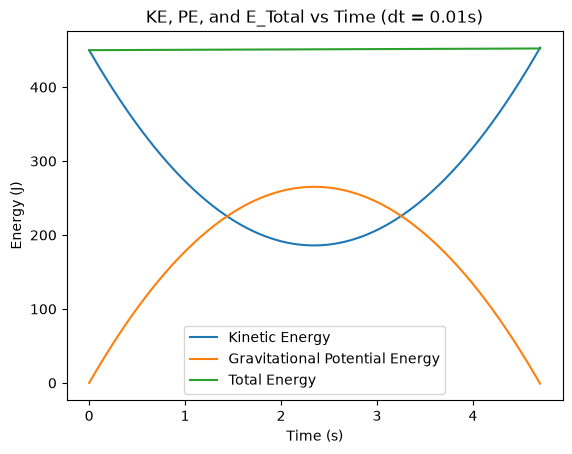

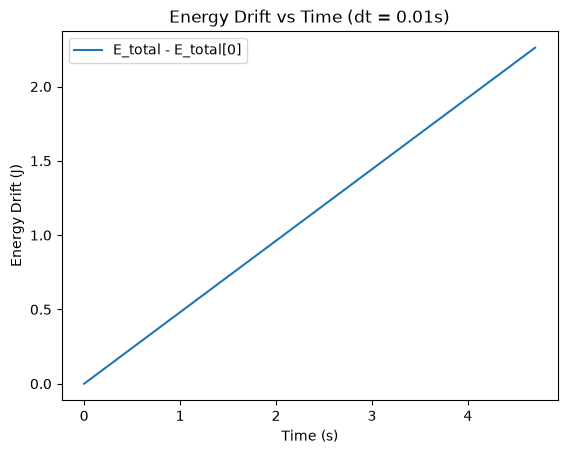

Maximum Energy Drift (J) :  2.26
Percent Increase From Initial Total Energy Of 450.0 (Joules) :  0.5
Therefore, Euler's Method Has An Error Of 0.5 % At dt = 0.01


In [2]:
# Parameters
v0 = 30
theta_deg = 50
dt = 0.01
g = 9.81

def simulate_projectile_2d(v0,theta_deg, dt, g):

    # Initialize Variables
    theta_rad = np.radians(theta_deg)
    y = 0.0
    x = 0.0
    vy = v0 * np.sin(theta_rad)
    vx = v0 * np.cos(theta_rad)
    t = 0.0
    m = 1
    ke = 0.5 * m * (vy**2 + vx**2)
    pe = m * g * y
    e_total = ke + pe

    # List Quantities
    t_arr, y_arr, x_arr, ke_arr, pe_arr, e_total_arr = [t], [y], [x], [ke], [pe], [e_total]

    # Euler Method
    while y >= 0:

        # Y-Axis Acceleration (Negative Direction)
        ay = -g

        # X-Axis Acceleration
        ax = 0

        # Update Quantities
        y = y + vy * dt
        x = x + vx * dt
        vy = vy + ay * dt
        vx = vx + ax * dt
        v = np.sqrt(vx**2 + vy**2)
        t = t + dt
        ke = 0.5 * m * (vy**2 + vx**2)
        pe = m * g * y
        e_total = ke + pe

        t_arr.append(t)
        y_arr.append(y)
        x_arr.append(x)
        ke_arr.append(ke)
        pe_arr.append(pe)
        e_total_arr.append(e_total)

    return t_arr, y_arr, x_arr, ke_arr, pe_arr, e_total_arr

t_arr, y_arr, x_arr, ke_arr, pe_arr, e_total_arr = simulate_projectile_2d(v0, theta_deg, dt, g)

# Plot Number 1 - KE, PE, and E_total vs Time
plt.plot(t_arr, ke_arr, label="Kinetic Energy")
plt.plot(t_arr, pe_arr, label="Gravitational Potential Energy")
plt.plot(t_arr, e_total_arr, label="Total Energy")
plt.title("KE, PE, and E_Total vs Time (dt = 0.01s)")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.legend()
plt.show()

# Plot Number 2 - Energy Drift vs Time
energy_drift = []
for e in e_total_arr:
    energy_drift.append(e - e_total_arr[0])


plt.plot(t_arr, energy_drift, label="E_total - E_total[0]")
plt.title("Energy Drift vs Time (dt = 0.01s)")
plt.xlabel("Time (s)")
plt.ylabel("Energy Drift (J)")
plt.legend()
plt.show()

max_energy_drift = round(energy_drift[-1], 2)
print("Maximum Energy Drift (J) : ", max_energy_drift)

initial_energy = round(e_total_arr[0], 2)
energy_diff = round(100.00 - ((initial_energy - max_energy_drift) / initial_energy) * 100, 2)

print("Percent Increase From Initial Total Energy Of", initial_energy, "(Joules) : ", energy_diff)
print("Therefore, Euler's Method Has An Error Of", energy_diff,"% At dt =", dt)

Interpretation -

The energy drift graph shows a linear relationship between the system's added energy over time. So, the drift does seem to be steady rather than accelerating. After further testing using other values of dt, the graph of energy drift stays linear for any dt value. For dt = 0.01, the Euler Method added approximately 0.5% of the initial energy to the system with this percentage increasing as dt increases.

Part B — Euler vs. Euler-Cromer

Description: Runs a simulate() function that now takes a new parameter, method. This parameter determines whether the Euler method or the Euler-Cromer method is used. This part runs both methods and plots their energy drift vs time as well as both of their trajectories.

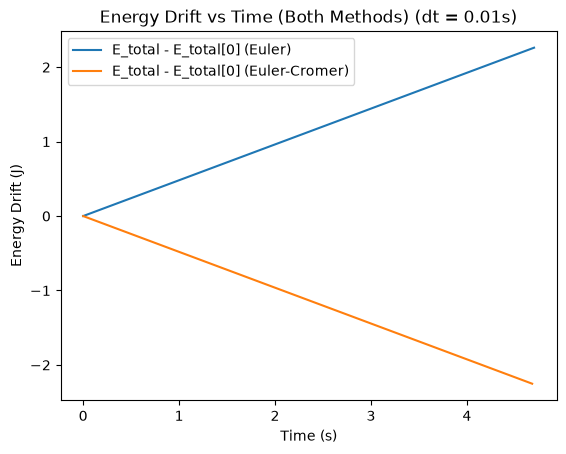

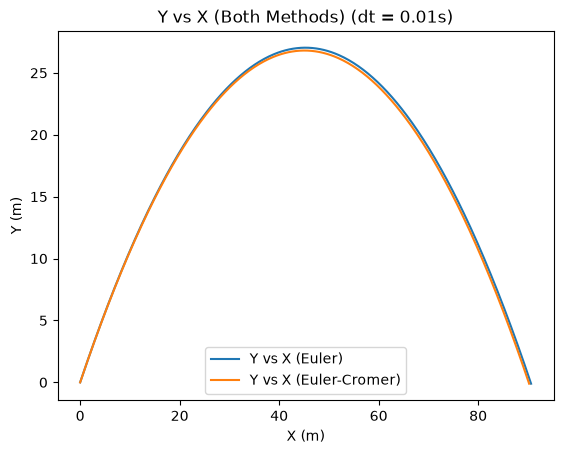

Range (Euler Method) in Meters :  90.63
Range (Euler-Cromer Method) in Meters :  90.25
So, the range in the Euler Method (X-Direction) is 0.38  meters further


In [3]:
# Parameters
v0 = 30
theta_deg = 50
dt = 0.01
g = 9.81

def simulate(method,v0,theta_deg, dt, g):

    # Initialize Variables
    theta_rad = np.radians(theta_deg)
    y = 0.0
    x = 0.0
    vy = v0 * np.sin(theta_rad)
    vx = v0 * np.cos(theta_rad)
    t = 0.0
    m = 1
    ke = 0.5 * m * (vy**2 + vx**2)
    pe = m * g * y
    e_total = ke + pe

    # List Quantities
    t_arr, y_arr, x_arr, e_total_arr = [t], [y], [x], [e_total]

    # Method
    while y >= 0:

        # Y-Axis Acceleration (Negative Direction)
        ay = -g

        # X-Axis Acceleration
        ax = 0

        # Update Quantities

        if(method == "euler"):
            y = y + vy * dt
            x = x + vx * dt
            vy = vy + ay * dt
            vx = vx + ax * dt

        if(method == "euler-cromer"):
            vy = vy + ay * dt
            vx = vx + ax * dt
            y = y + vy * dt
            x = x + vx * dt

        t = t + dt
        ke = 0.5 * m * (vy**2 + vx**2)
        pe = m * g * y
        e_total = ke + pe

        t_arr.append(t)
        y_arr.append(y)
        x_arr.append(x)
        e_total_arr.append(e_total)

    return np.array(t_arr), y_arr, x_arr, np.array(e_total_arr)

# Run Original Simulate 2D function using Euler method
t_euler, y_euler, x_euler, e_total_euler = simulate("euler", v0, theta_deg, dt, g)

# Run Simulate function using Euler-Cromer method
t_cromer, y_cromer, x_cromer, e_total_cromer = simulate("euler-cromer", v0, theta_deg, dt, g)

# Plot Number 1 - Energy Drift vs Time
plt.plot(t_euler, e_total_euler - e_total_euler[0], label="E_total - E_total[0] (Euler)")
plt.plot(t_cromer, e_total_cromer - e_total_cromer[0], label="E_total - E_total[0] (Euler-Cromer)")
plt.title("Energy Drift vs Time (Both Methods) (dt = 0.01s)")
plt.xlabel("Time (s)")
plt.ylabel("Energy Drift (J)")
plt.legend()
plt.show()

# Plot Number 2 - Trajectory Differences
plt.plot(x_euler, y_euler, label="Y vs X (Euler)")
plt.plot(x_cromer, y_cromer, label="Y vs X (Euler-Cromer)")
plt.title("Y vs X (Both Methods) (dt = 0.01s)")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.legend()
plt.show()

print("Range (Euler Method) in Meters : ", round(x_euler[-1], 2))
print("Range (Euler-Cromer Method) in Meters : ", round(x_cromer[-1], 2))
print("So, the range in the Euler Method (X-Direction) is", round(round(x_euler[-1], 2) - round(x_cromer[-1], 2), 2), " meters further")

Interpretaton - 

The plot of Energy Drift vs Time for the Euler-Cromer Method appears to be equal in magnitude but opposite in sign to the one for the Euler method. This difference in sign can be entirely attributed to the order in which the velocities are updated. The Euler method overestimates how high the projectile while travel because it does not account for the influence of gravity on the velocity vectors before calculating the new position. While on the other hand, the Euler-Cromer method underestimates how high the projectile will travel because the velocity vectors are updated first. This is supported by the position plots which clearly show that Euler-Cromer peaks at a lower y-value than the Euler method.

Part C — Convergence Study

Description: This section compares the absolute value of the energy drift at various dt values for both methods and plots them both on a log-log plot before estimating the slope (order) of each method.

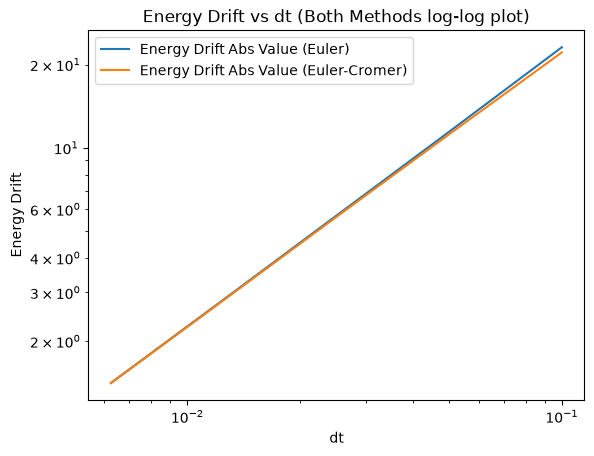

Estimated order (Euler Method) p = 1.01
Estimated order (Euler-Cromer Method) p = 0.99


In [4]:
# Parameters
v0 = 30
theta_deg = 50
g = 9.81

# Store each energy drift
euler_drift = []
cromer_drift = []
dt_arr = [0.1, 0.05, 0.025, 0.0125, 0.00625]

for i in range(5):
    euler_energy = simulate("euler", v0, theta_deg, dt_arr[i], g)[3]
    cromer_energy = simulate("euler-cromer", v0, theta_deg, dt_arr[i], g)[3]

    euler_drift.append(max(abs(np.array(euler_energy) - euler_energy[0])))
    cromer_drift.append(max(abs(np.array(cromer_energy) - cromer_energy[0])))


plt.loglog(dt_arr, euler_drift, label="Energy Drift Abs Value (Euler)")
plt.loglog(dt_arr, cromer_drift, label="Energy Drift Abs Value (Euler-Cromer)")
plt.title("Energy Drift vs dt (Both Methods log-log plot)")
plt.xlabel("dt")
plt.ylabel("Energy Drift")
plt.legend()
plt.show()

# Slope estimation
slope = np.polyfit(np.log(dt_arr), np.log(euler_drift), 1)[0]
print(f"Estimated order (Euler Method) p = {slope:.2f}")

slope = np.polyfit(np.log(dt_arr), np.log(cromer_drift), 1)[0]
print(f"Estimated order (Euler-Cromer Method) p = {slope:.2f}")

Analyze It -

1. The measured order of p for the standard Euler Method is p = 1.01. This value matches what the week 2 lesson predicted with the Euler Method being a known first order numerical method.
2. The energy drift of the Euler-Cromer method is nearly identical with only very small decreases in energy drift as dt increases. So, the energy drift does appear to be very slightly less with each dt step but not enough to claim it as the superior method in this case.
3. Both methods work almost identically for this particular simulation with neither method being clearly better. So, if I need energy drift within 0.01%, I would use step size dt = 0.001 since the energy drift for standard euler is close to 0.01% with this dt. As for which method, either method would work for reducing error within 0.01% as they are almost completely identically at any reasonable dt value.